In [1]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Baca gambar dan konversi BGR ke RGB (OpenCV membaca sebagai BGR)
img = cv2.imread('melon.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [3]:
def rgb_to_hsv_manual(img_rgb):
    img_normalized = img_rgb.astype(np.float32) / 255.0
    
    R = img_normalized[:, :, 0]
    G = img_normalized[:, :, 1]
    B = img_normalized[:, :, 2]
    
    Cmax = np.maximum(np.maximum(R, G), B)
    Cmin = np.minimum(np.minimum(R, G), B)
    delta = Cmax - Cmin
    
    H = np.zeros_like(R)
    S = np.zeros_like(R)
    V = Cmax
    
    mask_delta = delta != 0
    
    mask_r = (Cmax == R) & mask_delta
    H[mask_r] = 60 * (((G[mask_r] - B[mask_r]) / delta[mask_r]) % 6)
    
    mask_g = (Cmax == G) & mask_delta
    H[mask_g] = 60 * (((B[mask_g] - R[mask_g]) / delta[mask_g]) + 2)
    
    mask_b = (Cmax == B) & mask_delta
    H[mask_b] = 60 * (((R[mask_b] - G[mask_b]) / delta[mask_b]) + 4)
    
    mask_cmax = Cmax != 0
    S[mask_cmax] = delta[mask_cmax] / Cmax[mask_cmax]
    
    H = (H / 2).astype(np.uint8) 
    S = (S * 255).astype(np.uint8)
    V = (V * 255).astype(np.uint8)
    
    hsv_img = np.stack([H, S, V], axis=2)
    
    return hsv_img

In [4]:
def rgb_to_lab_manual(img_rgb):
    img_normalized = img_rgb.astype(np.float32) / 255.0
    
    R = img_normalized[:, :, 0]
    G = img_normalized[:, :, 1]
    B = img_normalized[:, :, 2]
    
    def gamma_correction(channel):
        mask = channel > 0.04045
        result = np.zeros_like(channel)
        result[mask] = np.power((channel[mask] + 0.055) / 1.055, 2.4)
        result[~mask] = channel[~mask] / 12.92
        return result
    
    R_linear = gamma_correction(R)
    G_linear = gamma_correction(G)
    B_linear = gamma_correction(B)
    
    X = R_linear * 0.4124564 + G_linear * 0.3575761 + B_linear * 0.1804375
    Y = R_linear * 0.2126729 + G_linear * 0.7151522 + B_linear * 0.0721750
    Z = R_linear * 0.0193339 + G_linear * 0.1191920 + B_linear * 0.9503041
    
    X = X / 0.95047
    Y = Y / 1.00000
    Z = Z / 1.08883
    
    def f_transform(t):
        delta = 6/29
        mask = t > delta**3
        result = np.zeros_like(t)
        result[mask] = np.power(t[mask], 1/3)
        result[~mask] = (t[~mask] / (3 * delta**2)) + (4/29)
        return result
    
    fX = f_transform(X)
    fY = f_transform(Y)
    fZ = f_transform(Z)
    
    L = 116 * fY - 16
    a = 500 * (fX - fY)
    b = 200 * (fY - fZ)
    
    L_scaled = (L * 255 / 100).clip(0, 255).astype(np.uint8)
    a_scaled = ((a + 128)).clip(0, 255).astype(np.uint8)
    b_scaled = ((b + 128)).clip(0, 255).astype(np.uint8)
    
    lab_img = np.stack([L_scaled, a_scaled, b_scaled], axis=2)
    
    return lab_img

In [5]:
# Aplikasikan konversi manual
hsv_manual = rgb_to_hsv_manual(img_rgb)
lab_manual = rgb_to_lab_manual(img_rgb)

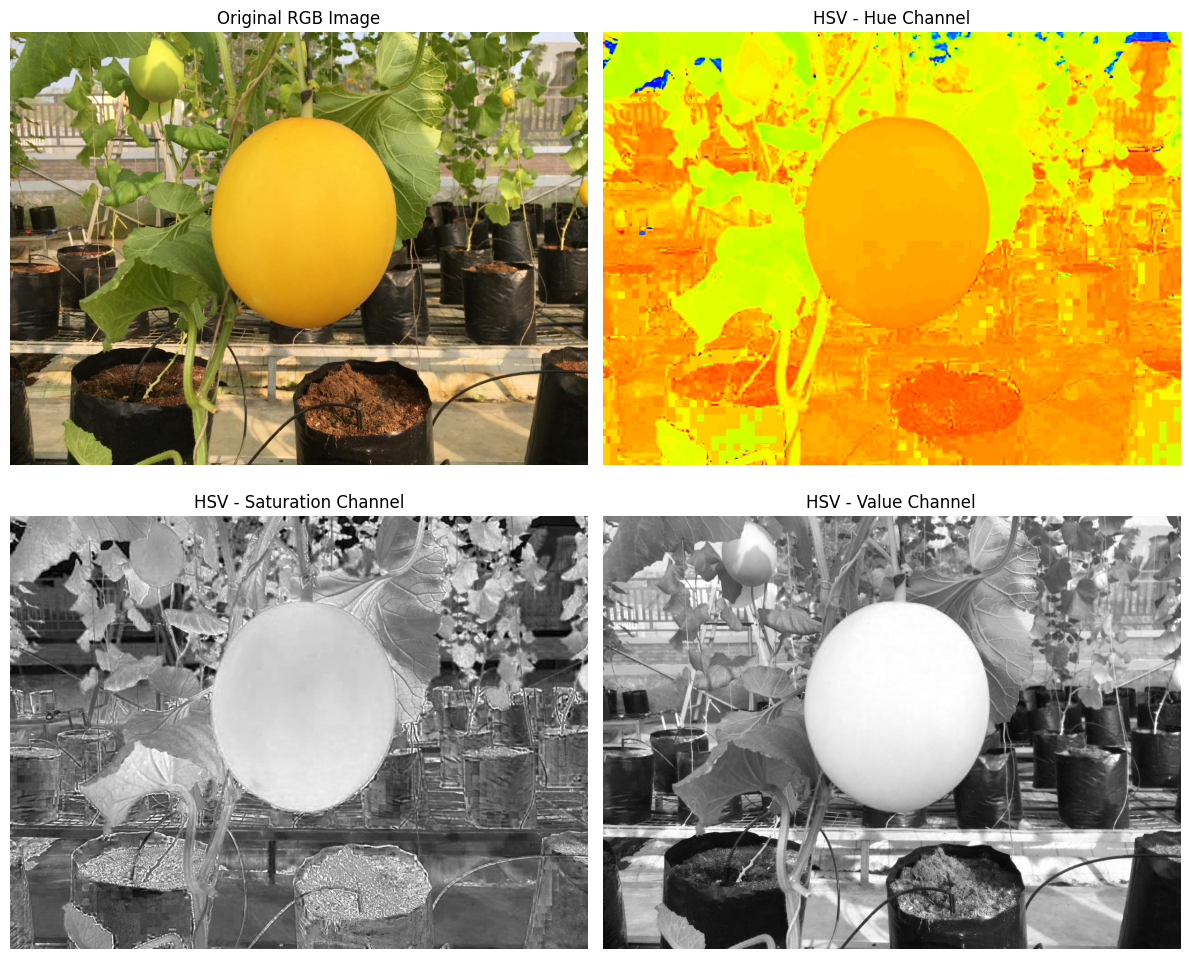

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Original RGB Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(hsv_manual[:, :, 0], cmap='hsv')
axes[0, 1].set_title('HSV - Hue Channel')
axes[0, 1].axis('off')

axes[1, 0].imshow(hsv_manual[:, :, 1], cmap='gray')
axes[1, 0].set_title('HSV - Saturation Channel')
axes[1, 0].axis('off')

axes[1, 1].imshow(hsv_manual[:, :, 2], cmap='gray')
axes[1, 1].set_title('HSV - Value Channel')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

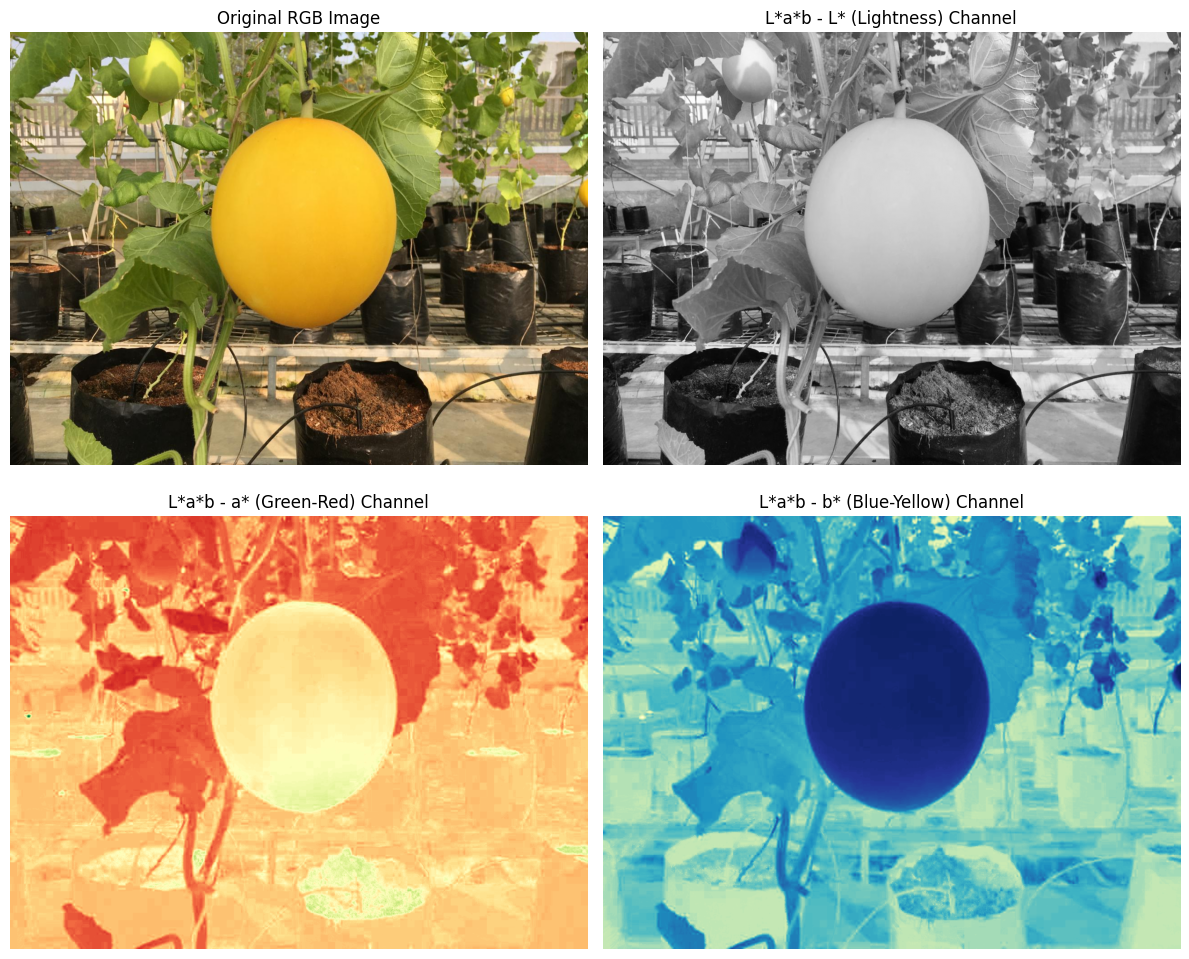

In [7]:
# Visualisasi Hasil Konversi L*a*b
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Original RGB Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(lab_manual[:, :, 0], cmap='gray')
axes[0, 1].set_title('L*a*b - L* (Lightness) Channel')
axes[0, 1].axis('off')

axes[1, 0].imshow(lab_manual[:, :, 1], cmap='RdYlGn')
axes[1, 0].set_title('L*a*b - a* (Green-Red) Channel')
axes[1, 0].axis('off')

axes[1, 1].imshow(lab_manual[:, :, 2], cmap='YlGnBu')
axes[1, 1].set_title('L*a*b - b* (Blue-Yellow) Channel')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [8]:
# Analisis statistik masing-masing channel L*a*b
L_channel = lab_manual[:, :, 0]
a_channel = lab_manual[:, :, 1]
b_channel = lab_manual[:, :, 2]

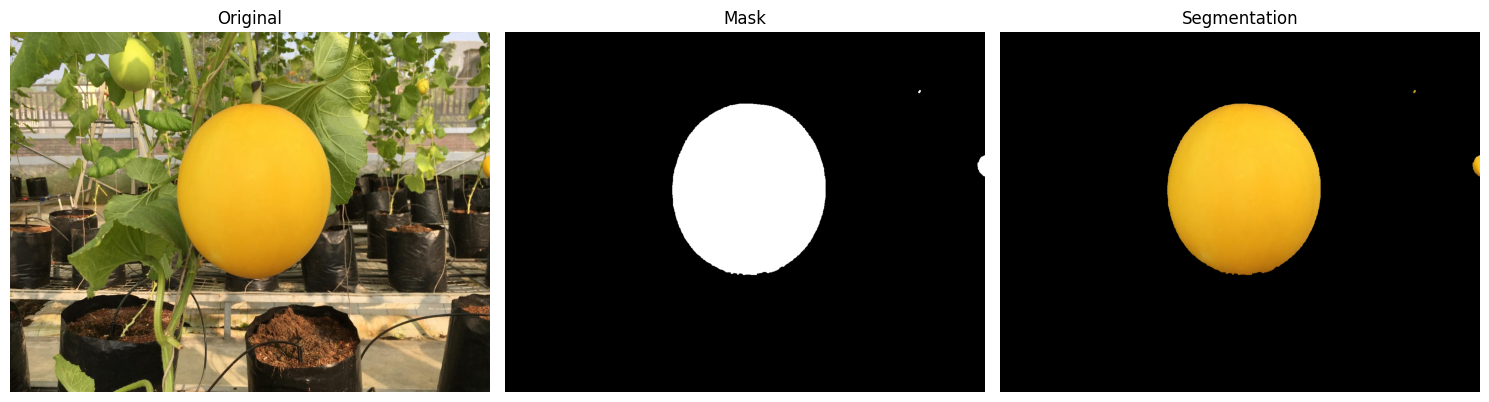

In [9]:
# Eksperimen (L, a, b) lower serta uppernya
lower = np.array([110, 128, 180])
upper = np.array([255, 255, 255])

mask = cv2.inRange(lab_manual, lower, upper)
kernel = np.ones((5,5), np.uint8)

# Operasi Opening: Menghapus noise titik-titik putih di background
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# Operasi Closing: Menambal lubang hitam/bolong di dalam siluet melon
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)


fig, axes = plt.subplots(1,3, figsize=(15, 10))

axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Mask')
axes[2].imshow(result)
axes[2].set_title('Segmentation')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()
